In [44]:
# imports
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import matplotlib
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN

In [45]:
# Load the .mat file
data = sio.loadmat('Xtrain.mat')
# Inspect the keys 
print(data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'Xtrain'])


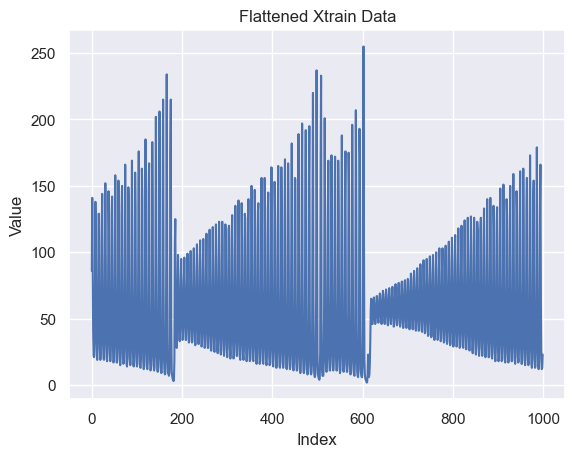

In [46]:
# plot flattened data
plt.plot(data['Xtrain'].flatten())
plt.title('Flattened Xtrain Data')
plt.xlabel('Index')
plt.ylabel('Value')
plt.show()

In [47]:
# reshape data
X_raw = data['Xtrain'].flatten()  # make 1D
print("Total samples:", len(X_raw))

Total samples: 1000


In [48]:
# # RNN: Data Preparation
def create_dataset(data, time_step=1):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:(i + time_step)])
        y.append(data[i + time_step])
    return np.array(X), np.array(y)


In [49]:
# create windows of data
window_size = 2
X, Y = create_dataset(X_raw, window_size)  # create windows of data

# X, Y = [], []
# for i in range(len(X_raw) - window_size):
#     X.append(X_raw[i:i+window_size])
#     Y.append(X_raw[i+window_size])  # next value as target
# X, Y = np.array(X), np.array(Y)

print("Shape of X:", X.shape)
print("Shape of Y:", Y.shape)

# overall data
X_raw


Shape of X: (998, 2)
Shape of Y: (998,)


array([ 86, 141,  95,  41,  22,  21,  32,  72, 138, 111,  48,  23,  19,
        27,  59, 129, 129,  58,  27,  19,  24,  46, 112, 144,  73,  30,
        20,  19,  37,  92, 152,  93,  36,  20,  18,  29,  71, 146, 117,
        46,  23,  18,  22,  52, 128, 142,  62,  26,  17,  19,  37, 100,
       158,  86,  32,  17,  17,  27,  72, 154, 118,  43,  20,  15,  21,
        47, 128, 150,  63,  24,  16,  17,  33,  92, 166,  95,  33,  16,
        14,  22,  58, 149, 137,  50,  20,  15,  16,  35, 106, 169,  82,
        28,  15,  14,  23,  65, 160, 133,  45,  18,  14,  16,  36, 111,
       176,  80,  26,  14,  13,  20,  60, 163, 140,  45,  18,  12,  14,
        30,  98, 185,  93,  28,  14,  12,  17,  46, 145, 167,  58,  19,
        11,  12,  21,  68, 183, 132,  38,  15,  11,  13,  26,  93, 202,
       100,  27,  12,  10,  13,  30, 114, 206,  82,  21,  11,   9,  10,
        30, 120, 215,  77,  20,  10,   8,   9,  21,  95, 234,  99,  22,
         9,   8,   7,   9,  35, 176, 215,  46,  11,   7,   5,   

In [50]:
# Reshape input to be [samples, time steps, features] which is required for RNN
X = X.reshape(X.shape[0], X.shape[1], 1)

# split data into train and test sets
split_index = int(len(X) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
Y_train, Y_test = Y[:split_index], Y[split_index:]

In [51]:
# Build the RNN Model
model = Sequential()
model.add(SimpleRNN(20, activation="relu", input_shape=(window_size, 1)))
model.add(Dense(1))
model.compile(optimizer="adam", loss="mse", metrics=["mae"])


In [52]:
# Train Model
model.fit(X_train, Y_train, epochs=100, verbose=1, validation_data=(X_test, Y_test)) # Training: The model is trained on the prepared data for 50 epochs. The verbose=1 option means progress will be printed during training.

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3379.9780 - mae: 40.3546 - val_loss: 2895.4463 - val_mae: 40.1578
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2952.5046 - mae: 37.5599 - val_loss: 2542.9053 - val_mae: 37.5725
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2647.3315 - mae: 35.1532 - val_loss: 2228.4548 - val_mae: 34.5830
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2379.9387 - mae: 32.9612 - val_loss: 1983.0118 - val_mae: 32.0597
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2174.8276 - mae: 31.1365 - val_loss: 1798.4042 - val_mae: 30.2230
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2010.6946 - mae: 29.7893 - val_loss: 1634.8800 - val_mae: 29.0586
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1874.5194 - mae: 28.6454 - val_loss: 1522.0314 - val_mae: 28.2169
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1781.4314 - mae: 28.0535 - val_loss: 1433.6257 - val_mae: 27.7078

In [53]:
# Make Forecast predictions
predictions = model.predict(X) # Predictions: The model makes predictions based on the input sequences in X.

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


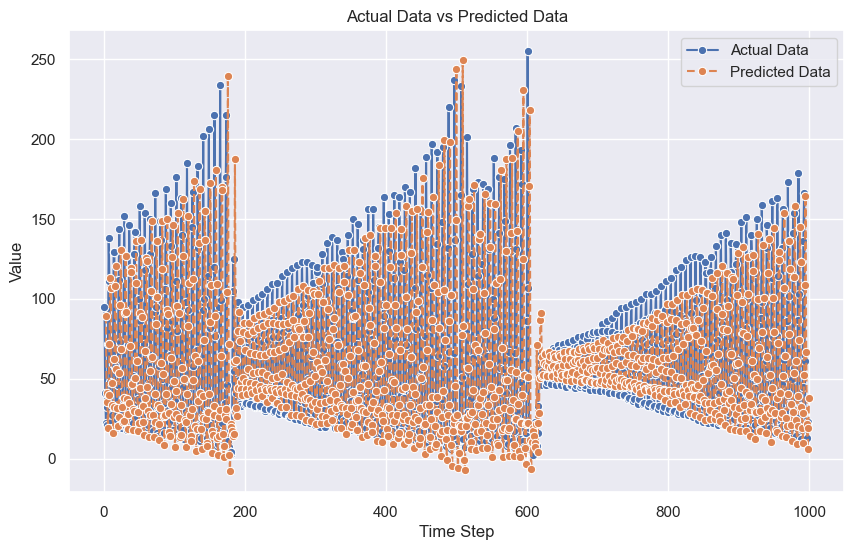

In [54]:
# Initialize the plot
sns.set(style="darkgrid")

# Plot actual data vs predictions using Seaborn
plt.figure(figsize=(10, 6))
sns.lineplot(x=range(1, len(X) + 1), y=Y, label='Actual Data', marker="o")
sns.lineplot(x=range(window_size + 1, len(predictions) + window_size + 1), y=predictions.flatten(), label='Predicted Data', linestyle='--', marker="o")

# Set plot labels and title
plt.ylabel('Value')
plt.xlabel('Time Step')
plt.title('Actual Data vs Predicted Data')
plt.legend()
plt.show()

In [55]:
# Print the last actual value and the predicted next value
print(f"Last actual value: {X_raw[-1]}")
next_value = model.predict(np.array([X_raw[-window_size:]]).reshape((1, window_size, 1)))
print(f"Predicted next value: {next_value[0][0]}")

Last actual value: 23


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Predicted next value: 65.22517395019531


In [56]:
# Evaluate the model on the test data
print("Evaluate on test data")
results = model.evaluate(X_test, Y_test, batch_size=128)
print("test loss (MSE), test MAE:", results)

# Generate predictions on 3 samples
print("\nGenerate predictions for 3 samples")
predictions = model.predict(X_test[:3])
print("predictions shape:", predictions.shape)
print("predicted values:", predictions.flatten())
print("actual values:   ", Y_test[:3])


Evaluate on test data
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 110.2295 - mae: 7.4950
test loss (MSE), test MAE: [110.22945404052734, 7.494962215423584]

Generate predictions for 3 samples
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
predictions shape: (3, 1)
predicted values: [42.48749  42.00405  34.706955]
actual values:    [41 29 31]
